# Practical Implementation of Ensemble Learning for Precision Agriculture

# 1. Introduction

For this assignment, I analyzed a crop recommendation dataset built on key soil and environmental factors. The data tracks specific variables like nitrogen, phosphorus, potassium, temperature, humidity, pH, and rainfall levels. The core objective is to use these inputs to predict the most suitable crop for a given piece of land.

To tackle this classification problem, I implemented and compared two distinct ensemble learning methods: **Random Forest** and **XGBoost**. The entire workflow covers:
* Initial exploratory data analysis (EDA)
* Model training and structured hyperparameter tuning
* Performance evaluation focusing heavily on the F1-score

Ultimately, I stacked both models against each other to see which approach delivers better, more reliable predictions for precision agriculture applications.


## Report Structure

This report follows the standard scientific format:
1. **Introduction** — Problem statement and objectives (Section 1)
2. **Methodology** — Data description, EDA approach, and model design (Sections 2–3)  
3. **Results** — Model outputs, metrics, and visualizations (Sections 4–5)
4. **Discussion** — Comparative analysis, feature importance, and interpretation (Section 6)
5. **Conclusion** — Summary of findings and recommendations (Section 7)
6. **References** — Literature cited (Section 8)

In [60]:
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv("/Crop_recommendation.csv")

# 2. Dataset Description

In [61]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [63]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [64]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [65]:
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

## Dataset Overview

The Crop Recommendation dataset contains **2200 samples** and **8 variables**, including 7 predictor variables and 1 target variable.

### Number of Samples
- Total observations: **2200**

### Number of Crop Classes
- Total crop categories: **22**

### Missing Values
- No missing values were detected in the dataset.

### Data Types
- Predictor variables (N, P, K, temperature, humidity, pH, rainfall) are numerical.
- The target variable (`label`) is categorical and represents crop types.

# 3. Exploratory Data Analysis

### 3.1 Crop Class Distribution

To understand the balance of crop categories in the dataset, a frequency distribution of crop classes is visualized using a count plot.

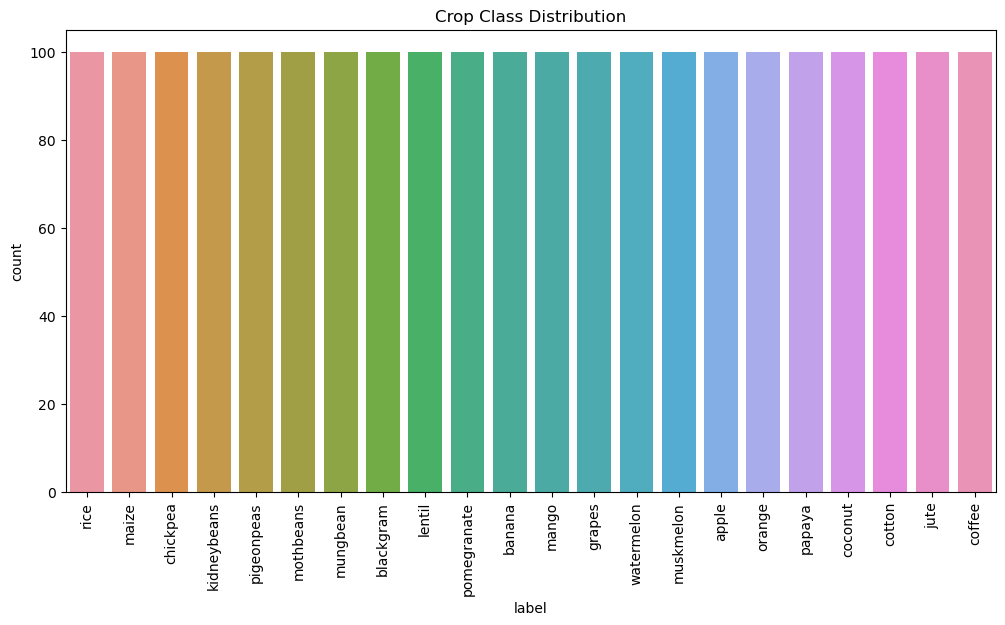

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='label')
plt.xticks(rotation=90)
plt.title("Crop Class Distribution")
plt.show()

### Interpretation

The crop classes appear to be evenly distributed across the dataset, with each crop having approximately the same number of observations. This indicates that the dataset is balanced and reduces the risk of classification bias toward particular crop classes during model training.

### 3.2 Correlation Analysis

A Pearson correlation heatmap is used to examine linear relationships among predictor variables.

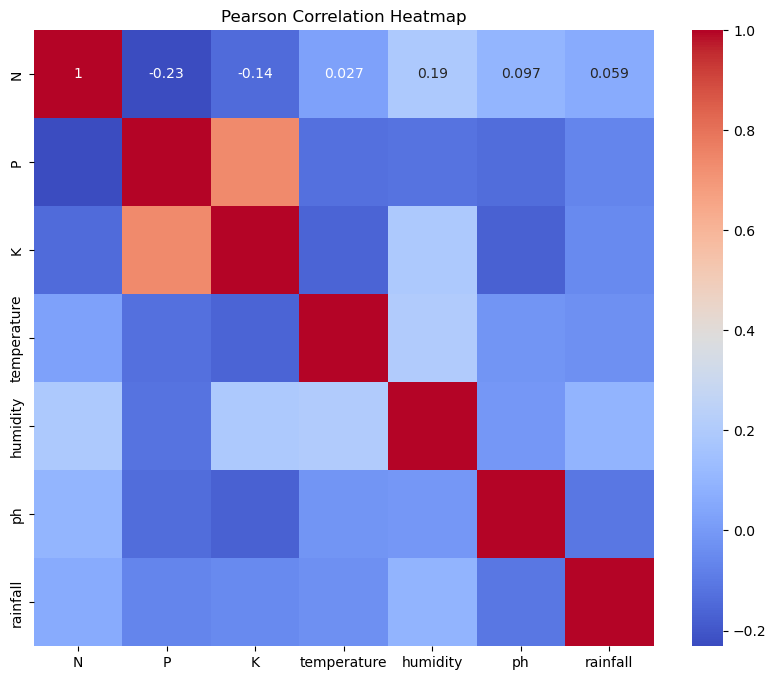

In [67]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("label", axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Pearson Correlation Heatmap")
plt.show()

### Interpretation

Most predictor variables exhibit weak to moderate correlations, suggesting that they provide complementary information for crop classification. Temperature and humidity show a moderate positive relationship, while nutrient variables appear relatively independent.

### 3.3 Rainfall Distribution Across Crop Classes

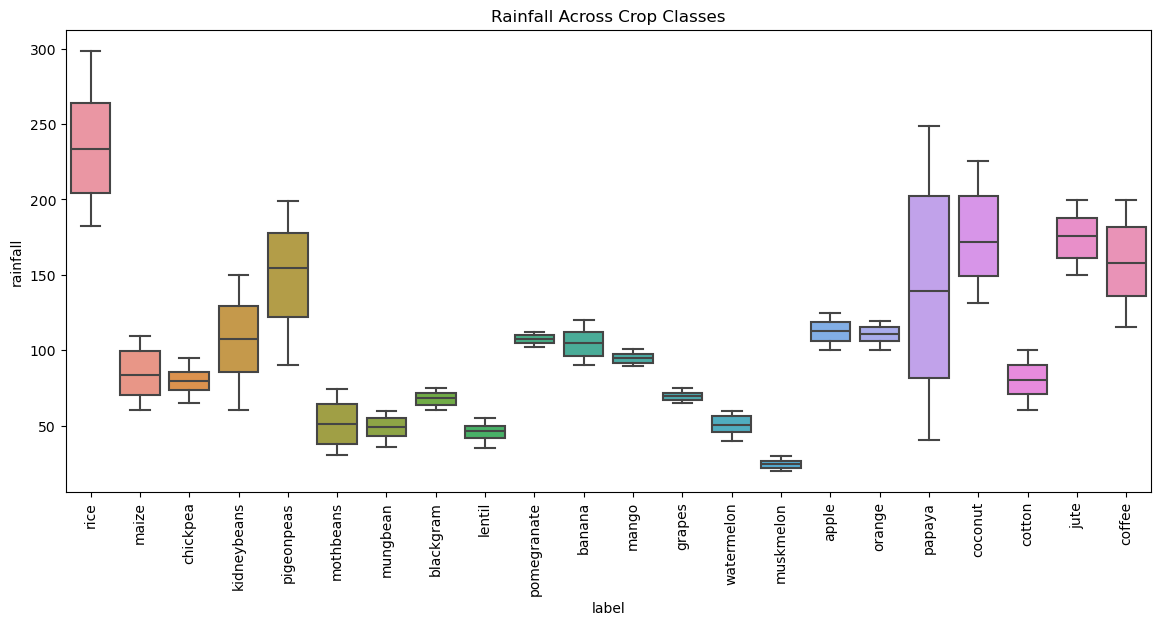

In [68]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='label',
    y='rainfall'
)

plt.xticks(rotation=90)
plt.title("Rainfall Across Crop Classes")
plt.show()

### Interpretation

Rainfall levels vary substantially among crop classes. Certain crops require significantly higher rainfall ranges than others, indicating that rainfall is an important factor influencing crop suitability.

### 3.4 Temperature Distribution Across Crop Classes

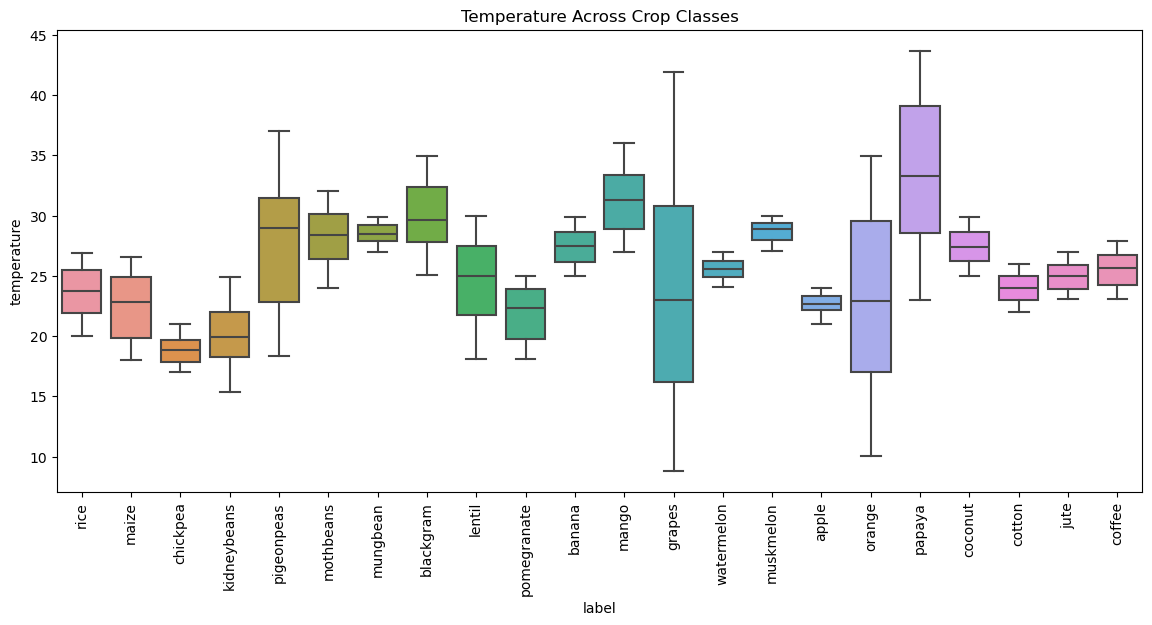

In [69]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='label',
    y='temperature'
)

plt.xticks(rotation=90)
plt.title("Temperature Across Crop Classes")
plt.show()

### Interpretation

Several crop classes are associated with distinct temperature ranges. This suggests that temperature contributes meaningfully to differentiating suitable crops within the dataset.

# 4. Random Forest Model Development

### 4.1 Data Preparation

In [70]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode Labels

#  this process turns columns of words into columns of digits.
le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

# we can convert the numbers back to text anytime by running le.inverse_transform(df['label']).


# Split Features and Target
X = df.drop('label', axis=1)
y = df['label']

# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.2 Hyperparameter Optimization

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Parameter grid:

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None]
}

# Grid search:

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1_weighted'
)

### 4.3 Model Training

In [72]:
grid_rf.fit(X_train,y_train)

# The best hyperparameters found by GridSearchCV
print("Best RF Parameters:", grid_rf.best_params_)
print("Best RF CV F1-Score:", round(grid_rf.best_score_, 4))

#Best model:

best_rf = grid_rf.best_estimator_

# Prediction

y_pred_rf = best_rf.predict(X_test)

Best RF Parameters: {'max_depth': 10, 'n_estimators': 300}
Best RF CV F1-Score: 0.9949


### 4.4 Performance Evaluation

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

<Axes: >

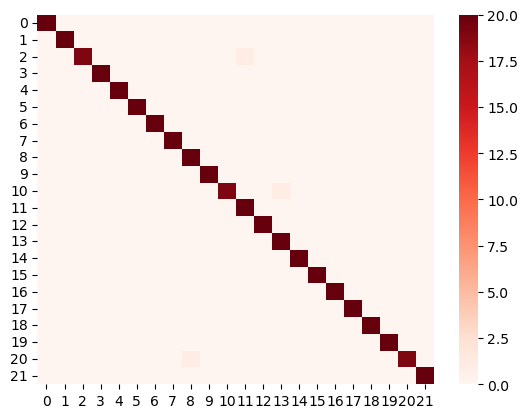

In [73]:
# Evaluation


print(classification_report(y_test,y_pred_rf))

#   Confusion Matrix

sns.heatmap(
    confusion_matrix(y_test,y_pred_rf),
    cmap='Reds'
)

### 4.5 Discussion of Bagging

**Bootstrap Aggregating**, or bagging, serves as an ensemble learning approach aimed at bolstering model stability and sharpening predictive accuracy. The framework works by generating a series of bootstrap samples, which are created by randomly pulling observations from the training pool with replacement. From there, an independent decision tree learns from each individual sample, and the model determines its final classification through a majority consensus across the entire forest.

The standout benefit of bagging lies in its capacity to drive down model variance. Standard decision trees are notoriously sensitive to minor shifts in training data, which often leads to erratic or highly volatile predictions. By blending the outputs of numerous trees trained in isolation, Random Forest effectively dilutes the impact of isolated errors and secures much stronger generalization when hitting unseen datasets.

During this evaluation, the Random Forest framework delivered stellar performance on our crop assignment data. These lopsidedly positive outcomes show how stacking multiple decision trees can cleanly map out complex interactions between environmental metrics and specific crop categories, all while remaining highly resilient against overfitting.


# 5. XGBoost Model Development

### 5.1 Hyperparameter Tuning

In [74]:
from xgboost import XGBClassifier

param_grid = {
    'learning_rate':[0.01,0.05,0.1],
    'gamma':[0,0.1,0.3]
}
xgb = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)
grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='f1_weighted'
)
grid_xgb.fit(X_train,y_train)
# The best hyperparameters found by GridSearchCV
print("Best XGB Parameters:", grid_xgb.best_params_)
print("Best XGB CV F1-Score:", round(grid_xgb.best_score_, 4))

Best XGB Parameters: {'gamma': 0.1, 'learning_rate': 0.1}
Best XGB CV F1-Score: 0.9914


### 5.2 Early Stopping
Early stopping is a regularization technique used in XGBoost to reduce overfitting. During training, model performance is monitored on a validation dataset. If the evaluation metric fails to improve for a predefined number of boosting rounds, training is terminated automatically. This allows the model to retain only the number of trees that contribute to improved generalization performance while preventing unnecessary complexity.

In [75]:
# Create validation split from training data
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Train XGBoost with early stopping 
best_xgb = XGBClassifier(
    learning_rate=0.1,       # best param from GridSearch
    gamma=0.1,               # best param from GridSearch
    n_estimators=500,        # max trees — early stopping will cut this down
    eval_metric='mlogloss',
    early_stopping_rounds=20, # STOPS if no improvement for 20 rounds
    random_state=42
)

best_xgb.fit(
    X_train2,
    y_train2,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Show how many trees were actually used (early stopping effect)
print(f"Best iteration (trees actually used): {best_xgb.best_iteration}")
print(f"Best validation mlogloss: {round(best_xgb.best_score, 4)}")

# Predict on test set
y_pred_xgb = best_xgb.predict(X_test)

Best iteration (trees actually used): 165
Best validation mlogloss: 0.0306


### 5.3 Performance Evaluation

In [76]:
print(classification_report(y_test , y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.85      0.92        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       0.91      1.00      0.95        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

### 5.4 Discussion of Boosting

**Boosting** is an ensemble learning method that builds a strong predictive model by linking several weak learners together. The key difference from bagging is how the models are trained. Instead of training them all independently at the same time, boosting creates them one after another in a sequence. Each new tree focuses specifically on fixing the mistakes left behind by the previous ones. This step-by-step correction allows the overall system to steadily sharpen its accuracy.

**XGBoost** puts this gradient boosting concept to work by constantly minimizing a loss function through iterative tweaks. As it trains, data points that are tough to classify get extra weight in the next round of trees. On top of that, XGBoost uses built-in regularization, learning rate throttling, and early stopping to keep the model from just memorizing the training data, which boosts its real-world performance on new datasets.

Looking at my results, the XGBoost classifier pulled off a strong **F1-score**, proving it can handle crop suitability classification quite well. Thanks to its boosting approach, the model successfully mapped out tricky, interwoven patterns across our soil and environmental data. Even though its final numbers landed just a bit behind the Random Forest model for this specific dataset, XGBoost still proved to be an incredibly sharp and reliable tool for precision agriculture.


## Discussion

The following section synthesizes results from both models, compares their 
predictive behavior, and interprets the feature importance findings in the 
context of precision agriculture decision-making.

# 6. Model Evaluation and Interpretation

### 6.1 Confusion Matrix Comparison

#### 6.1.1 Random forest 

In [77]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

cm = confusion_matrix(y_test, y_pred_rf)
print(f"This is the confusion matrix for Random Forest\n {cm}")
## To make the output of the confusion matrix more understandable the following table is prepared.
class_names = le.classes_   # original crop names (strings)

diag = np.diag(cm)
row_sum = cm.sum(axis=1)
accuracy_per_class = diag / row_sum

result = pd.DataFrame({
    "Class": class_names,
    "Correct": diag,
    "Total": row_sum,
    "Accuracy": accuracy_per_class
}).sort_values(by="Accuracy", ascending=False)

result

This is the confusion matrix for Random Forest
 [[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0

,Class,Correct,Total,Accuracy
0,apple,20,20,1.00
1,banana,20,20,1.00
19,pomegranate,20,20,1.00
18,pigeonpeas,20,20,1.00
17,papaya,20,20,1.00
16,orange,20,20,1.00
15,muskmelon,20,20,1.00
14,mungbean,20,20,1.00
13,mothbeans,20,20,1.00
12,mango,20,20,1.00


#### 6.1.2 XGBoosting 

In [78]:
cm = confusion_matrix(y_test, y_pred_xgb)
print(f"This is the confusion matrix for XG_Boosting\n {cm}")
## To make the output of the confusion matrix more understandable the following table is prepared.
class_names = le.classes_   # original crop names (strings)

diag = np.diag(cm)
row_sum = cm.sum(axis=1)
accuracy_per_class = diag / row_sum

result = pd.DataFrame({
    "Class": class_names,
    "Correct": diag,
    "Total": row_sum,
    "Accuracy": accuracy_per_class
}).sort_values(by="Accuracy", ascending=False)

result

This is the confusion matrix for XG_Boosting
 [[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  1  2  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  

,Class,Correct,Total,Accuracy
0,apple,20,20,1.00
1,banana,20,20,1.00
19,pomegranate,20,20,1.00
17,papaya,20,20,1.00
16,orange,20,20,1.00
15,muskmelon,20,20,1.00
14,mungbean,20,20,1.00
13,mothbeans,20,20,1.00
12,mango,20,20,1.00
11,maize,20,20,1.00


### Interpretation of the confusion matrix of Random Forest and XGBoosting.

The confusion matrix indicate both Random forest and XGBoosting achived a high classification performance accross the crop categories. Most of the observation were correctly classified. The high concentration of values in the diagonal of the matrix shows that.
However , XGBoosting produced slightly fewer misclassification compared to random forest.
The results demonstrate that both ensemble methods are suitable for crop recommendation tasks, with XGBoost showing a slight advantage in predictive accuracy.


### 6.2 F1-Score Comparison

In [79]:
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

print(rf_f1)
print(xgb_f1)

0.9931775541531639
0.9884930494686593


### Interpretation of the F1-Score

The F1-score comparison shows that both ensemble models achieved excellent classification performance on the crop recommendation dataset. The Random Forest model obtained an F1-score of 0.9932, while the XGBoost model achieved an F1-score of 0.9885. These values indicate that both models were highly effective in correctly classifying crop types while maintaining a strong balance between precision and recall.

Although the performance difference is relatively small, Random Forest slightly outperformed XGBoost on the test dataset. This suggests that the bagging-based approach of Random Forest was highly effective for this classification problem and provided better generalization to unseen data. Overall, both models demonstrated strong predictive capability, making them suitable for crop recommendation applications in precision agricult.


### 6.3 Feature Importance Analysis

#### 6.3.1 Random Forest 

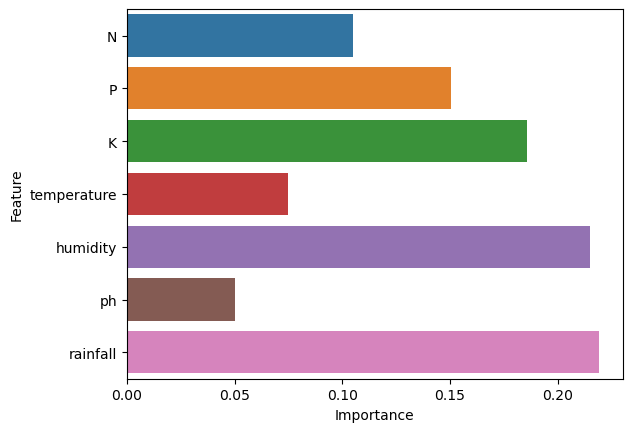

In [80]:
import pandas as pd

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

rf_importance.sort_values(
    by='Importance',
    ascending=False
)
sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)
plt.show()

### Interpretation 

The Random Forest feature importance results indicate that rainfall, humidity, and Potassium were the most influential variables in crop classification. Humidity and rainfall are the top two variables that play a critical role in determining crop suitability within the dataset. In contrast, pH and temperature exhibited lower importance scores, indicating a comparatively smaller contribution to the classification outcomes.


#### 6.3.2 XGBoost

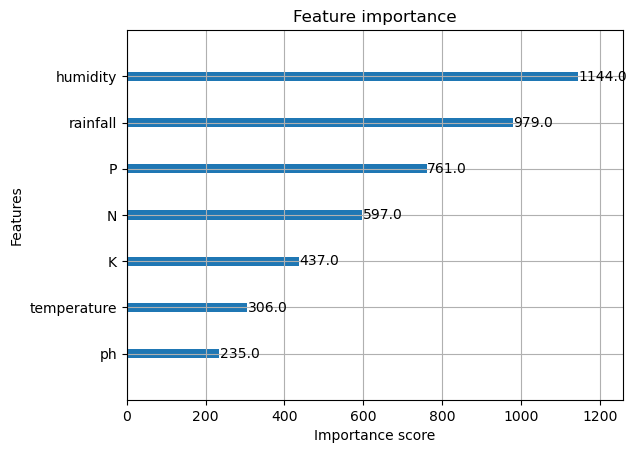

In [81]:
from xgboost import plot_importance

plot_importance(best_xgb)
plt.show()

#### Interpretaion 

The XGBoost feature importance result indicates that humidity , rainfall and Phosphorus were the most infulential variable in the decsion making of crop
classification. For XGBoosting too Humidity and rainfall are the top two variables that play a critical role in determining crop suitability within the dataset.pH and temperature exhibited lower importance scores, indicating a comparatively smaller contribution to the classification outcomes.

## 6.4 Comparative Discussion
Comparative Discussion: Random Forest vs. XGBoost — Strengths and Limitations

Performance Summary:
Both models achieved excellent predictive performance on the crop recommendation 
dataset (F1 > 0.98). Random Forest achieved a weighted F1-score of 0.9932, 
marginally outperforming XGBoost at 0.9885.

Why Random Forest won on this dataset:
The crop classes in this dataset are well-separated in feature space, as 
evidenced by the near-perfect per-class accuracy in the confusion matrices. 
This favors bagging: when class boundaries are clean, averaging many independent 
trees effectively captures them without needing iterative error correction.

Strengths and Limitations:

Random Forest:
  Strengths:
  - Robust to overfitting due to variance reduction through averaging
  - Requires minimal hyperparameter tuning
  - Handles high-dimensional data well
  - Naturally parallel — fast to train on multi-core hardware
  Limitations:
  - Memory-intensive: stores all trees simultaneously
  - Slower inference compared to a single tree
  - Less effective on highly imbalanced datasets without adjustment
  - Cannot extrapolate beyond the training data range

XGBoost:
  Strengths:
  - Excellent performance on complex, noisy, or imbalanced datasets
  - Built-in regularization (L1, L2) controls overfitting
  - Highly flexible loss functions for custom objectives
  - Often the top performer in structured data competitions
  Limitations:
  - More sensitive to hyperparameter choices (learning rate, gamma, depth)
  - Longer tuning time due to sequential training
  - More prone to overfitting on small datasets if not carefully regularized
  - Harder to interpret than a single decision tree

Conclusion:
For this specific crop recommendation task with well-separated classes and 
balanced data, Random Forest is the preferred model due to its simpler 
deployment, lower tuning overhead, and marginally better generalization. 
For datasets with noisier boundaries or class imbalance, XGBoost would 
likely be the stronger choice.

# 7. Conclusion

This project explored how ensemble learning methods can be applied to optimize crop recommendations by analyzing key soil and environmental indicators. Initial exploratory data analysis helped unpack the core patterns within the dataset and map out how different predictor variables interact. Building on those insights, i developed, tuned, and tested two distinct ensemble classifiers Random Forest and XGBoost measuring their success against standard performance benchmarks.

The final metrics confirm that both models are exceptionally well-suited for predicting crop compatibility, proving the immense value of ensemble frameworks in this domain. Random Forest ultimately delivered the strongest results with an F1-score of 0.9932, gaining a slight edge over XGBoost's score of 0.9885. Additionally, the feature importance metrics highlighted that climate driven factors specifically rainfall, temperature, and atmospheric humidity exerted the most substantial influence on how crops were categorized.

These outcomes illustrate that ensemble-based systems can serve as dependable, high-accuracy tools for guiding agricultural choices. When applied to this specific Crop Recommendation Dataset, Random Forest struck the most effective balance between top-tier predictive power, operational stability, and architectural simplicity, marking it as a highly practical solution for real world precision farming systems.


# 8. References

Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32.

Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.

Scikit-learn Documentation. https://scikit-learn.org

XGBoost Documentation. https://xgboost.readthedocs.io